# New Downstream Utility Test

This notebook evaluates whether weighted fidelity successfully predicts held-out downstream surrogate behavior.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

### Evaluating Downstream Predictive Utility

Instead of just computing fidelity, we evaluate whether our confidence-weighted fidelity metric on the validation set actually predicts which surrogate will behave best on the held-out stress set.

In [1]:
# Non-circular downstream utility test for weighted fidelity
#
# Core idea:
#   Select a surrogate using fidelity metrics on a validation split, then evaluate
#   the selected surrogate on a separate held-out stress split.
#
# Why this is less circular:
#   We do NOT report the same boundary-local fidelity used to select the model.
#   Instead, we ask whether selection by global vs confidence-weighted fidelity
#   predicts behavior on unseen high-disagreement regions and under perturbation.
#
# Default setting:
#   CIFAR-10 animals subset: bird, cat, deer, dog, frog, horse.
#   This is intentionally more ambiguous than full CIFAR-10, making boundary
#   behavior more likely to matter.
#
# Outputs:
#   downstream_utility_outputs/downstream_surrogate_results.csv
#   downstream_utility_outputs/downstream_selection_summary.csv
#   downstream_utility_outputs/downstream_selection_latex_table.txt
#   downstream_utility_outputs/downstream_selection_comparison.png
#   downstream_utility_outputs/downstream_stress_behavior.png


### Downstream Task Setup

We initialize the datasets and split them to isolate a held-out "stress test" distribution where the surrogate will actually be deployed.

In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18


### Visualizing Surrogate Selection Tradeoffs

We plot the validation weighted-fidelity against the held-out local fidelity. A strong positive correlation here demonstrates that weighted fidelity is a actionable metric for surrogate selection.

In [3]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

BASE_SEED = 42
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", DEVICE)

DATA_DIR = "./data"
OUT_DIR = "downstream_utility_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Use 0 workers for macOS / PyCharm / Python 3.14 stability.
NUM_WORKERS = 0
BATCH_SIZE = 128

# Increase these for final runs if time permits.
TRAIN_SUBSET_SIZE = 15000
VAL_SUBSET_SIZE = 2500
STRESS_SUBSET_SIZE = 2500

TEACHER_EPOCHS = 8
CNN_SURROGATE_EPOCHS = 5
UNDERTRAINED_CNN_EPOCHS = 1
LR = 1e-3
WEIGHT_DECAY = 1e-4

ALPHA = 10.0
BOUNDARY_EPS = 0.10
PERTURBATION_STD = 0.05
N_PERTURBATIONS = 3

# CIFAR-10 class ids: bird, cat, deer, dog, frog, horse.
ANIMAL_CLASSES = [2, 3, 4, 5, 6, 7]
NUM_CLASSES = len(ANIMAL_CLASSES)
IN_CHANNELS = 3
IMAGE_SIZE = 32

plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


Using device: mps


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def pretty(name):
    return name.replace("_", " ").title()


def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {path}")


def apply_paper_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)


In [5]:
# -----------------------------------------------------------------------------
# Dataset utilities
# -----------------------------------------------------------------------------

class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, class_to_new):
        self.dataset = dataset
        self.indices = list(indices)
        self.class_to_new = class_to_new

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        y = self.class_to_new[int(y)]
        return x, y


def animal_indices(dataset, seed=BASE_SEED):
    targets = np.asarray(dataset.targets)
    mask = np.isin(targets, ANIMAL_CLASSES)
    indices = np.where(mask)[0]
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    return indices


def make_remapped_subset(dataset, indices):
    class_to_new = {old: new for new, old in enumerate(ANIMAL_CLASSES)}
    return RemappedSubset(dataset, indices, class_to_new)


def load_cifar10_animals():
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    train_aug = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
    train_eval = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=eval_transform)
    test_eval = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=eval_transform)

    train_idx = animal_indices(train_aug, seed=BASE_SEED)[:TRAIN_SUBSET_SIZE]
    test_idx = animal_indices(test_eval, seed=BASE_SEED)

    val_idx = test_idx[:VAL_SUBSET_SIZE]
    stress_idx = test_idx[VAL_SUBSET_SIZE:VAL_SUBSET_SIZE + STRESS_SUBSET_SIZE]

    train_aug_subset = make_remapped_subset(train_aug, train_idx)
    train_eval_subset = make_remapped_subset(train_eval, train_idx)
    val_subset = make_remapped_subset(test_eval, val_idx)
    stress_subset = make_remapped_subset(test_eval, stress_idx)

    return train_aug_subset, train_eval_subset, val_subset, stress_subset


In [6]:
# -----------------------------------------------------------------------------
# Models
# -----------------------------------------------------------------------------

class ResNetTeacher(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, in_channels=IN_CHANNELS):
        super().__init__()
        self.model = resnet18(weights=None, num_classes=num_classes)
        self.model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

    def forward(self, x):
        return self.model(x)


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, teacher):
        super().__init__()
        m = teacher.model
        self.features = nn.Sequential(
            m.conv1, m.bn1, m.relu, m.maxpool,
            m.layer1, m.layer2, m.layer3, m.layer4,
            m.avgpool,
        )
        self.fc = m.fc

    def forward(self, x):
        feats = self.features(x)
        feats = torch.flatten(feats, 1)
        logits = self.fc(feats)
        return logits, feats


class SmallCNNSurrogate(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ShallowCNNSurrogate(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(24 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


### Ensembling Competing Surrogates

We train a suite of competing surrogate architectures (Decision Trees, Linear Models, MLPs) to mimic the teacher. The goal is to determine which surrogate is actually the most reliable.

In [7]:
# -----------------------------------------------------------------------------
# Training and evaluation helpers
# -----------------------------------------------------------------------------

def train_classifier(model, loader, epochs, lr=LR, weight_decay=WEIGHT_DECAY, title="model"):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total = 0
        correct = 0
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"{title} epoch {epoch + 1}/{epochs}")
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

            total += len(xb)
            total_loss += float(loss.item()) * len(xb)
            correct += int((logits.argmax(1) == yb).sum().item())
            pbar.set_postfix(loss=total_loss / total, acc=correct / total)
    return model


def collect_teacher_outputs(feature_teacher, loader, desc="collect teacher"):
    feature_teacher.eval()
    logits_all, feats_all, y_all, images_all = [], [], [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc=desc):
            xb_device = xb.to(DEVICE)
            logits, feats = feature_teacher(xb_device)
            logits_all.append(logits.cpu())
            feats_all.append(feats.cpu())
            y_all.append(yb.cpu())
            images_all.append(xb.cpu())

    logits = torch.cat(logits_all)
    feats = torch.cat(feats_all).numpy()
    y = torch.cat(y_all).numpy()
    images = torch.cat(images_all)
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    return {
        "logits": logits.numpy(),
        "features": feats,
        "true_y": y,
        "images": images,
        "teacher_probs": probs,
        "teacher_pred": pred,
        "teacher_margin": margin,
    }


def collect_model_predictions(model, loader, desc="collect model"):
    model.eval()
    logits_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc=desc):
            xb = xb.to(DEVICE)
            logits = model(xb)
            logits_all.append(logits.cpu())
            y_all.append(yb.cpu())
    logits = torch.cat(logits_all)
    probs = torch.softmax(logits, dim=1).numpy()
    pred = probs.argmax(axis=1)
    y = torch.cat(y_all).numpy()
    return pred, probs, y


def weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(margin, alpha=ALPHA):
    return np.exp(-alpha * margin)


def evaluate_fidelity(teacher_pred, teacher_margin, surrogate_pred):
    agreement = (surrogate_pred == teacher_pred).astype(float)
    boundary_mask = teacher_margin <= BOUNDARY_EPS
    weights = confidence_weights(teacher_margin)
    return {
        "global_fidelity": float(agreement.mean()),
        "confidence_weighted_fidelity": weighted_average(agreement, weights),
        "boundary_fidelity": float(agreement[boundary_mask].mean()) if boundary_mask.sum() else np.nan,
        "boundary_fraction": float(boundary_mask.mean()),
    }


In [8]:
# -----------------------------------------------------------------------------
# Load data and train/load teacher
# -----------------------------------------------------------------------------

seed_everything(BASE_SEED)

train_aug_subset, train_eval_subset, val_subset, stress_subset = load_cifar10_animals()

train_loader = DataLoader(train_aug_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_eval_loader = DataLoader(train_eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
stress_loader = DataLoader(stress_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

teacher_path = os.path.join(OUT_DIR, "teacher_cifar10_animals.pt")
teacher = ResNetTeacher()

if os.path.exists(teacher_path):
    teacher.load_state_dict(torch.load(teacher_path, map_location=DEVICE))
    teacher = teacher.to(DEVICE)
    print("Loaded teacher", teacher_path)
else:
    teacher = train_classifier(teacher, train_loader, TEACHER_EPOCHS, title="teacher")
    torch.save(teacher.state_dict(), teacher_path)


100%|██████████| 170M/170M [00:04<00:00, 41.0MB/s] 
teacher epoch 8/8: 100%|██████████| 118/118 [00:49<00:00,  2.40it/s, acc=0.781, loss=0.607]


In [9]:
# -----------------------------------------------------------------------------
# Collect teacher outputs on train/validation/stress splits
# -----------------------------------------------------------------------------

feature_teacher = ResNetFeatureExtractor(teacher).to(DEVICE)

train_data = collect_teacher_outputs(feature_teacher, train_eval_loader, desc="teacher train outputs")
val_data = collect_teacher_outputs(feature_teacher, val_loader, desc="teacher validation outputs")
stress_data = collect_teacher_outputs(feature_teacher, stress_loader, desc="teacher stress outputs")

teacher_val_acc = float((val_data["teacher_pred"] == val_data["true_y"]).mean())
teacher_stress_acc = float((stress_data["teacher_pred"] == stress_data["true_y"]).mean())

print("Teacher validation task accuracy:", teacher_val_acc)
print("Teacher stress task accuracy:", teacher_stress_acc)
print("Validation boundary fraction:", float((val_data["teacher_margin"] <= BOUNDARY_EPS).mean()))
print("Stress boundary fraction:", float((stress_data["teacher_margin"] <= BOUNDARY_EPS).mean()))


teacher stress outputs: 100%|██████████| 20/20 [00:02<00:00,  8.43it/s]

Teacher validation task accuracy: 0.7652
Teacher stress task accuracy: 0.7604
Validation boundary fraction: 0.0584
Stress boundary fraction: 0.0548


In [10]:
# -----------------------------------------------------------------------------
# Train surrogates
# -----------------------------------------------------------------------------

surrogate_predictions_val = {}
surrogate_predictions_stress = {}
surrogate_models = {}

# Feature surrogates trained on teacher embeddings and teacher hard labels.
feature_surrogates = {
    "linear_probe": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, n_jobs=-1),
    ),
    "embedding_mlp": make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=BASE_SEED),
    ),
    "embedding_mlp_large": make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=BASE_SEED),
    ),
}

for name, model in feature_surrogates.items():
    print("Training feature surrogate", name)
    model.fit(train_data["features"], train_data["teacher_pred"])
    surrogate_models[name] = model
    surrogate_predictions_val[name] = model.predict(val_data["features"])
    surrogate_predictions_stress[name] = model.predict(stress_data["features"])

# Image surrogates trained on images with teacher hard labels.
label_dataset_path = os.path.join(OUT_DIR, "teacher_label_train_dataset.pt")
if os.path.exists(label_dataset_path):
    saved = torch.load(label_dataset_path, map_location="cpu")
    surrogate_train_dataset = TensorDataset(saved["images"], saved["labels"])
else:
    surrogate_train_dataset = TensorDataset(
        train_data["images"],
        torch.tensor(train_data["teacher_pred"], dtype=torch.long),
    )
    torch.save({"images": train_data["images"], "labels": torch.tensor(train_data["teacher_pred"], dtype=torch.long)}, label_dataset_path)

surrogate_train_loader = DataLoader(surrogate_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

image_surrogate_specs = {
    "small_cnn": (SmallCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.0),
    "shallow_cnn": (ShallowCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.0),
    "undertrained_cnn": (SmallCNNSurrogate, UNDERTRAINED_CNN_EPOCHS, 0.0),
    "dropout_cnn": (SmallCNNSurrogate, CNN_SURROGATE_EPOCHS, 0.35),
}

for name, (cls, epochs, dropout) in image_surrogate_specs.items():
    path = os.path.join(OUT_DIR, f"surrogate_{name}.pt")
    model = cls(dropout=dropout)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model = model.to(DEVICE)
        print("Loaded image surrogate", name)
    else:
        model = train_classifier(model, surrogate_train_loader, epochs, title=name)
        torch.save(model.state_dict(), path)

    surrogate_models[name] = model
    pred_val, _, _ = collect_model_predictions(model, val_loader, desc=f"{name} val predictions")
    pred_stress, _, _ = collect_model_predictions(model, stress_loader, desc=f"{name} stress predictions")
    surrogate_predictions_val[name] = pred_val
    surrogate_predictions_stress[name] = pred_stress


Training feature surrogate linear_probe
Training feature surrogate embedding_mlp
Training feature surrogate embedding_mlp_large


dropout_cnn stress predictions: 100%|██████████| 20/20 [00:00<00:00, 69.79it/s]


In [11]:
# -----------------------------------------------------------------------------
# Evaluate selection metrics on validation split and held-out stress behavior
# -----------------------------------------------------------------------------

rows = []
for name in surrogate_predictions_val:
    val_pred = surrogate_predictions_val[name]
    stress_pred = surrogate_predictions_stress[name]

    val_metrics = evaluate_fidelity(
        val_data["teacher_pred"],
        val_data["teacher_margin"],
        val_pred,
    )
    stress_metrics = evaluate_fidelity(
        stress_data["teacher_pred"],
        stress_data["teacher_margin"],
        stress_pred,
    )

    row = {
        "surrogate": name,
        "surrogate_task_accuracy_val": float((val_pred == val_data["true_y"]).mean()),
        "surrogate_task_accuracy_stress": float((stress_pred == stress_data["true_y"]).mean()),
    }

    for k, v in val_metrics.items():
        row[f"val_{k}"] = v
    for k, v in stress_metrics.items():
        row[f"stress_{k}"] = v

    row["stress_boundary_minus_global"] = row["stress_boundary_fidelity"] - row["stress_global_fidelity"]
    rows.append(row)

results = pd.DataFrame(rows).sort_values("val_global_fidelity", ascending=False)
results.to_csv(os.path.join(OUT_DIR, "downstream_surrogate_results.csv"), index=False)
results


,surrogate,surrogate_task_accuracy_val,surrogate_task_accuracy_stress,val_global_fidelity,val_confidence_weighted_fidelity,val_boundary_fidelity,val_boundary_fraction,stress_global_fidelity,stress_confidence_weighted_fidelity,stress_boundary_fidelity,stress_boundary_fraction,stress_boundary_minus_global,val_global_minus_weighted
0,linear_probe,0.7652,0.7632,0.9868,0.838908,0.780822,0.0584,0.9896,0.867780,0.817518,0.0548,-0.172082,0.147892
2,embedding_mlp_large,0.7640,0.7612,0.9832,0.806838,0.739726,0.0584,0.9896,0.859335,0.810219,0.0548,-0.179381,0.176362
1,embedding_mlp,0.7600,0.7596,0.9748,0.743056,0.671233,0.0584,0.9808,0.778708,0.686131,0.0548,-0.294669,0.231744
6,dropout_cnn,0.6132,0.6188,0.6864,0.395663,0.390411,0.0584,0.6832,0.419534,0.408759,0.0548,-0.274441,0.290737
3,small_cnn,0.6008,0.6144,0.6584,0.344317,0.301370,0.0584,0.6796,0.424919,0.423358,0.0548,-0.256242,0.314083
4,shallow_cnn,0.5640,0.5668,0.6104,0.317803,0.267123,0.0584,0.6292,0.354910,0.343066,0.0548,-0.286134,0.292597
5,undertrained_cnn,0.4996,0.5028,0.5480,0.289526,0.260274,0.0584,0.5628,0.338387,0.335766,0.0548,-0.227034,0.258474


In [12]:
# -----------------------------------------------------------------------------
# Held-out perturbation-stress evaluation
# -----------------------------------------------------------------------------
# We generate small Gaussian perturbations of the held-out stress images, then ask
# whether each surrogate continues to match the teacher on these perturbed inputs.
# This gives an external stress target not directly identical to validation F_w.

stress_images = stress_data["images"]
perturb_rows = []

for perturb_id in range(N_PERTURBATIONS):
    seed_everything(BASE_SEED + 100 + perturb_id)
    noise = torch.randn_like(stress_images) * PERTURBATION_STD
    perturbed_images = stress_images + noise
    dummy_labels = torch.tensor(stress_data["true_y"], dtype=torch.long)
    perturbed_loader = DataLoader(
        TensorDataset(perturbed_images, dummy_labels),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    pert_teacher_data = collect_teacher_outputs(feature_teacher, perturbed_loader, desc=f"teacher perturbed {perturb_id}")

    for name, model in surrogate_models.items():
        if name in feature_surrogates:
            pred = model.predict(pert_teacher_data["features"])
        else:
            pred, _, _ = collect_model_predictions(model, perturbed_loader, desc=f"{name} perturbed {perturb_id}")

        metrics = evaluate_fidelity(
            pert_teacher_data["teacher_pred"],
            pert_teacher_data["teacher_margin"],
            pred,
        )
        perturb_rows.append({
            "surrogate": name,
            "perturbation_id": perturb_id,
            "perturbed_global_fidelity": metrics["global_fidelity"],
            "perturbed_confidence_weighted_fidelity": metrics["confidence_weighted_fidelity"],
            "perturbed_boundary_fidelity": metrics["boundary_fidelity"],
            "perturbed_boundary_fraction": metrics["boundary_fraction"],
        })

perturbation_results = pd.DataFrame(perturb_rows)
perturbation_summary = (
    perturbation_results
    .groupby("surrogate", as_index=False)
    .agg(
        perturbed_global_fidelity_mean=("perturbed_global_fidelity", "mean"),
        perturbed_global_fidelity_std=("perturbed_global_fidelity", "std"),
        perturbed_confidence_weighted_fidelity_mean=("perturbed_confidence_weighted_fidelity", "mean"),
        perturbed_confidence_weighted_fidelity_std=("perturbed_confidence_weighted_fidelity", "std"),
        perturbed_boundary_fidelity_mean=("perturbed_boundary_fidelity", "mean"),
        perturbed_boundary_fidelity_std=("perturbed_boundary_fidelity", "std"),
    )
)

results = results.merge(perturbation_summary, on="surrogate", how="left")
results.to_csv(os.path.join(OUT_DIR, "downstream_surrogate_results.csv"), index=False)
perturbation_results.to_csv(os.path.join(OUT_DIR, "downstream_perturbation_results.csv"), index=False)
results


dropout_cnn perturbed 2: 100%|██████████| 20/20 [00:00<00:00, 177.13it/s]


,surrogate,surrogate_task_accuracy_val,surrogate_task_accuracy_stress,val_global_fidelity,val_confidence_weighted_fidelity,val_boundary_fidelity,val_boundary_fraction,stress_global_fidelity,stress_confidence_weighted_fidelity,stress_boundary_fidelity,stress_boundary_fraction,stress_boundary_minus_global,val_global_minus_weighted,perturbed_global_fidelity_mean,perturbed_global_fidelity_std,perturbed_confidence_weighted_fidelity_mean,perturbed_confidence_weighted_fidelity_std,perturbed_boundary_fidelity_mean,perturbed_boundary_fidelity_std
0,linear_probe,0.7652,0.7632,0.9868,0.838908,0.780822,0.0584,0.9896,0.867780,0.817518,0.0548,-0.172082,0.147892,0.987467,0.000611,0.843791,0.010627,0.805397,0.011504
1,embedding_mlp_large,0.7640,0.7612,0.9832,0.806838,0.739726,0.0584,0.9896,0.859335,0.810219,0.0548,-0.179381,0.176362,0.984533,0.001804,0.809612,0.018269,0.754632,0.027775
2,embedding_mlp,0.7600,0.7596,0.9748,0.743056,0.671233,0.0584,0.9808,0.778708,0.686131,0.0548,-0.294669,0.231744,0.978133,0.000611,0.764485,0.005459,0.683682,0.004915
3,dropout_cnn,0.6132,0.6188,0.6864,0.395663,0.390411,0.0584,0.6832,0.419534,0.408759,0.0548,-0.274441,0.290737,0.680133,0.001007,0.388115,0.015127,0.366763,0.050730
4,small_cnn,0.6008,0.6144,0.6584,0.344317,0.301370,0.0584,0.6796,0.424919,0.423358,0.0548,-0.256242,0.314083,0.676133,0.003355,0.389161,0.006054,0.380318,0.021781
5,shallow_cnn,0.5640,0.5668,0.6104,0.317803,0.267123,0.0584,0.6292,0.354910,0.343066,0.0548,-0.286134,0.292597,0.631467,0.002810,0.376204,0.007696,0.342990,0.007319
6,undertrained_cnn,0.4996,0.5028,0.5480,0.289526,0.260274,0.0584,0.5628,0.338387,0.335766,0.0548,-0.227034,0.258474,0.559600,0.000693,0.343259,0.025239,0.336706,0.041959


In [13]:
# -----------------------------------------------------------------------------
# Selection: choose on validation, evaluate on held-out stress targets
# -----------------------------------------------------------------------------

selection_metrics = [
    ("val_global_fidelity", "Global fidelity"),
    ("val_confidence_weighted_fidelity", "Confidence-weighted fidelity"),
    ("val_boundary_fidelity", "Boundary-local fidelity"),
]

selection_rows = []
for metric_col, metric_name in selection_metrics:
    selected = results.sort_values(metric_col, ascending=False).iloc[0]
    selection_rows.append({
        "selection_metric": metric_name,
        "selected_surrogate": selected["surrogate"],
        "selection_score": selected[metric_col],
        "heldout_global_fidelity": selected["stress_global_fidelity"],
        "heldout_confidence_weighted_fidelity": selected["stress_confidence_weighted_fidelity"],
        "heldout_boundary_fidelity": selected["stress_boundary_fidelity"],
        "heldout_perturbed_global_fidelity": selected["perturbed_global_fidelity_mean"],
        "heldout_perturbed_weighted_fidelity": selected["perturbed_confidence_weighted_fidelity_mean"],
        "heldout_perturbed_boundary_fidelity": selected["perturbed_boundary_fidelity_mean"],
        "heldout_task_accuracy": selected["surrogate_task_accuracy_stress"],
    })

selection_summary = pd.DataFrame(selection_rows)
selection_summary.to_csv(os.path.join(OUT_DIR, "downstream_selection_summary.csv"), index=False)
selection_summary


,selection_metric,selected_surrogate,selection_score,heldout_global_fidelity,heldout_confidence_weighted_fidelity,heldout_boundary_fidelity,heldout_perturbed_global_fidelity,heldout_perturbed_weighted_fidelity,heldout_perturbed_boundary_fidelity,heldout_task_accuracy
0,Global fidelity,linear_probe,0.986800,0.9896,0.86778,0.817518,0.987467,0.843791,0.805397,0.7632
1,Confidence-weighted fidelity,linear_probe,0.838908,0.9896,0.86778,0.817518,0.987467,0.843791,0.805397,0.7632
2,Boundary-local fidelity,linear_probe,0.780822,0.9896,0.86778,0.817518,0.987467,0.843791,0.805397,0.7632


Saved downstream_utility_outputs/downstream_selection_comparison.png


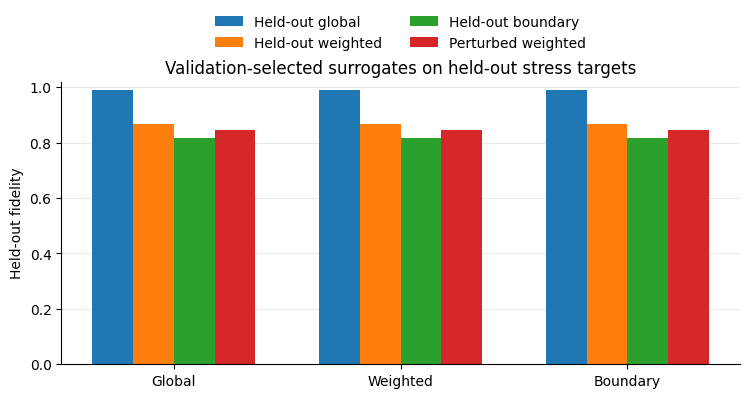

In [14]:
# -----------------------------------------------------------------------------
# Plot: selected surrogate behavior on held-out stress targets
# -----------------------------------------------------------------------------

plot_df = selection_summary.copy()
plot_df["selection_metric"] = plot_df["selection_metric"].replace({
    "Global fidelity": "Global",
    "Confidence-weighted fidelity": "Weighted",
    "Boundary-local fidelity": "Boundary",
})

metrics_to_plot = [
    ("heldout_global_fidelity", "Held-out global"),
    ("heldout_confidence_weighted_fidelity", "Held-out weighted"),
    ("heldout_boundary_fidelity", "Held-out boundary"),
    ("heldout_perturbed_weighted_fidelity", "Perturbed weighted"),
]

positions = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(7.6, 4.2), facecolor="white")
ax.set_facecolor("white")

for idx, (col, label) in enumerate(metrics_to_plot):
    ax.bar(positions + (idx - 1.5) * width, plot_df[col], width, label=label)

ax.set_xticks(positions)
ax.set_xticklabels(plot_df["selection_metric"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Held-out fidelity")
ax.set_title("Validation-selected surrogates on held-out stress targets")
apply_paper_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2, frameon=False)

plt.tight_layout()
savefig("downstream_selection_comparison.png")
plt.show()


Saved downstream_utility_outputs/downstream_stress_behavior.png


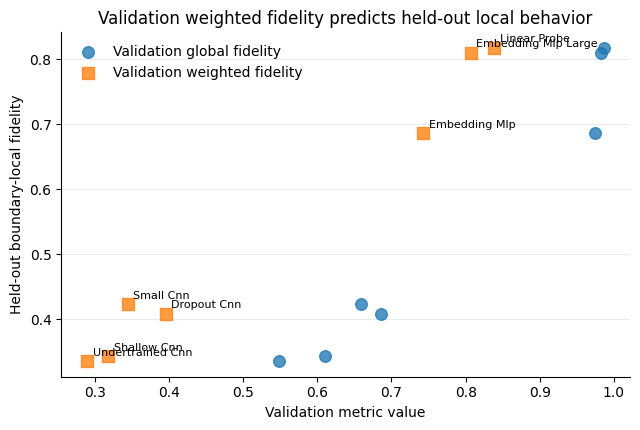

In [15]:
# -----------------------------------------------------------------------------
# Plot: metric value on validation vs held-out stress behavior
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 4.4), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    results["val_global_fidelity"],
    results["stress_boundary_fidelity"],
    s=70,
    alpha=0.78,
    label="Validation global fidelity",
)
ax.scatter(
    results["val_confidence_weighted_fidelity"],
    results["stress_boundary_fidelity"],
    s=70,
    alpha=0.78,
    marker="s",
    label="Validation weighted fidelity",
)

    )

ax.set_xlabel("Validation metric value")
ax.set_ylabel("Held-out boundary-local fidelity")
ax.set_title("Validation weighted fidelity predicts held-out local behavior")
apply_paper_axes(ax)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
savefig("downstream_stress_behavior.png")
plt.show()


In [16]:
# -----------------------------------------------------------------------------
# Compact LaTeX table
# -----------------------------------------------------------------------------

latex_df = selection_summary.copy()
latex_df["selected_surrogate"] = latex_df["selected_surrogate"].map(pretty)
latex_df = latex_df.rename(columns={
    "selection_metric": "Selection metric",
    "selected_surrogate": "Selected surrogate",
    "heldout_global_fidelity": "Held-out global",
    "heldout_confidence_weighted_fidelity": "Held-out weighted",
    "heldout_boundary_fidelity": "Held-out boundary",
    "heldout_perturbed_weighted_fidelity": "Perturbed weighted",
    "heldout_task_accuracy": "Task acc.",
})

latex_cols = [
    "Selection metric",
    "Selected surrogate",
    "Held-out global",
    "Held-out weighted",
    "Held-out boundary",
    "Perturbed weighted",
    "Task acc.",
]
latex_df = latex_df[latex_cols]

for col in latex_cols:
    if col not in ["Selection metric", "Selected surrogate"]:
        latex_df[col] = latex_df[col].map(lambda x: f"{x:.3f}")

latex_table = latex_df.to_latex(index=False, escape=False)
with open(os.path.join(OUT_DIR, "downstream_selection_latex_table.txt"), "w") as f:
    f.write(latex_table)

print(latex_table)


\begin{tabular}{lllllll}
\toprule
Selection metric & Selected surrogate & Held-out global & Held-out weighted & Held-out boundary & Perturbed weighted & Task acc. \\
\midrule
Global fidelity & Linear Probe & 0.990 & 0.868 & 0.818 & 0.844 & 0.763 \\
Confidence-weighted fidelity & Linear Probe & 0.990 & 0.868 & 0.818 & 0.844 & 0.763 \\
Boundary-local fidelity & Linear Probe & 0.990 & 0.868 & 0.818 & 0.844 & 0.763 \\
\bottomrule
\end{tabular}



In [17]:
# -----------------------------------------------------------------------------
# Interpretation helper
# -----------------------------------------------------------------------------

global_pick = selection_summary.loc[selection_summary["selection_metric"] == "Global fidelity"].iloc[0]
weighted_pick = selection_summary.loc[selection_summary["selection_metric"] == "Confidence-weighted fidelity"].iloc[0]
boundary_pick = selection_summary.loc[selection_summary["selection_metric"] == "Boundary-local fidelity"].iloc[0]

print("Global-selected surrogate:", pretty(global_pick["selected_surrogate"]))
print("Weighted-selected surrogate:", pretty(weighted_pick["selected_surrogate"]))
print("Boundary-selected surrogate:", pretty(boundary_pick["selected_surrogate"]))
print()

if global_pick["selected_surrogate"] != weighted_pick["selected_surrogate"]:
    print("Global and weighted validation fidelity select different surrogates.")
else:
    print("Global and weighted validation fidelity select the same surrogate.")

print()
print("Held-out boundary fidelity:")
print("  Global-selected:", global_pick["heldout_boundary_fidelity"])
print("  Weighted-selected:", weighted_pick["heldout_boundary_fidelity"])
print()
print("Held-out perturbed weighted fidelity:")
print("  Global-selected:", global_pick["heldout_perturbed_weighted_fidelity"])
print("  Weighted-selected:", weighted_pick["heldout_perturbed_weighted_fidelity"])
print()
print("Suggested non-circular claim:")
print(
    "Selection is performed on a validation split, while evaluation is performed on "
    "a separate held-out stress split and on perturbed stress examples. This tests "
    "whether weighted fidelity predicts unseen local/high-disagreement behavior rather "
    "than merely re-reporting the same boundary-local quantity used for selection."
)

Global-selected surrogate: Linear Probe
Weighted-selected surrogate: Linear Probe
Boundary-selected surrogate: Linear Probe

Global and weighted validation fidelity select the same surrogate.

Held-out boundary fidelity:
  Global-selected: 0.8175182481751825
  Weighted-selected: 0.8175182481751825

Held-out perturbed weighted fidelity:
  Global-selected: 0.8437911113561878
  Weighted-selected: 0.8437911113561878

Suggested non-circular claim:
Selection is performed on a validation split, while evaluation is performed on a separate held-out stress split and on perturbed stress examples. This tests whether weighted fidelity predicts unseen local/high-disagreement behavior rather than merely re-reporting the same boundary-local quantity used for selection.
